# ASTR-154 Final Project - Exoplanet Obliquity Angle
## File: hypothesis_testing
This file contains to code for performing hypothesis testing on two sets of obliquity angle data in order to determine whether they belong to different distributions based on the obliquity angle value and their systems "binarity"

Author: Babak Aryan

### 1. Hypothesis Testing

In this setion we divide the data into two sets... and perfomr hypothesis testing to determine whether the two sets come from the same distribution or not.

In [1]:
from IPython.display import display, Math
from astropy import table
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in the Exoplanet data generated from the "NASA Exoplanet Archive" database
# This particular list conatins only exoplanets with listed project obliquity values
data_file_loc = '../data/'
exo_file_name = 'NASA-Exoplanet-Archive-20260514.csv'
exo_table = table.Table.read(data_file_loc+exo_file_name, format='ascii.csv', header_start=123)

In [3]:
# exo_table.mask['pl_name']
masked_columns = [[col, np.ma.count_masked(exo_table[col]).tolist()] for col in exo_table.colnames if np.any(exo_table.mask[col])]
print(masked_columns)
exo_table.colnames

[['pl_orbper', 21], ['pl_orbpererr1', 35], ['pl_orbpererr2', 35], ['pl_orbperlim', 21], ['pl_orbsmax', 111], ['pl_orbsmaxerr1', 114], ['pl_orbsmaxerr2', 114], ['pl_orbsmaxlim', 111], ['pl_rade', 58], ['pl_radeerr1', 61], ['pl_radeerr2', 61], ['pl_radelim', 58], ['pl_radj', 58], ['pl_radjerr1', 61], ['pl_radjerr2', 61], ['pl_radjlim', 58], ['pl_masse', 76], ['pl_masseerr1', 91], ['pl_masseerr2', 91], ['pl_masselim', 76], ['pl_massj', 76], ['pl_massjerr1', 91], ['pl_massjerr2', 91], ['pl_massjlim', 76], ['pl_bmasse', 74], ['pl_bmasseerr1', 89], ['pl_bmasseerr2', 89], ['pl_bmasselim', 74], ['pl_bmassj', 74], ['pl_bmassjerr1', 89], ['pl_bmassjerr2', 89], ['pl_bmassjlim', 74], ['pl_bmassprov', 74], ['pl_orbeccen', 67], ['pl_orbeccenerr1', 177], ['pl_orbeccenerr2', 177], ['pl_orbeccenlim', 67], ['pl_insol', 241], ['pl_insolerr1', 241], ['pl_insolerr2', 241], ['pl_insollim', 241], ['pl_eqt', 166], ['pl_eqterr1', 166], ['pl_eqterr2', 166], ['pl_eqtlim', 166], ['pl_projobliqerr1', 2], ['pl_proj

['pl_name',
 'hostname',
 'pl_letter',
 'gaia_dr2_id',
 'gaia_dr3_id',
 'gaia_dr3_source_id',
 'gaia_query_id',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'discoverymethod',
 'disc_year',
 'disc_facility',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_masse',
 'pl_masseerr1',
 'pl_masseerr2',
 'pl_masselim',
 'pl_massj',
 'pl_massjerr1',
 'pl_massjerr2',
 'pl_massjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_orbeccen',
 'pl_orbeccenerr1',
 'pl_orbeccenerr2',
 'pl_orbeccenlim',
 'pl_insol',
 'pl_insolerr1',
 'pl_insolerr2',
 'pl_insollim',
 'pl_eqt',
 'pl_eqterr1',
 'pl_eqterr2',
 'pl_eqtlim',
 'ttv_flag',
 'pl_proj

In [4]:
exo_table_subdata = exo_table['pl_rade']
print(exo_table_subdata[~exo_table_subdata.mask])
# print(exo_table_subdata[exo_table_subdata['pl_rade'] is not None])

  pl_rade  
-----------
   16.58932
   15.58051
      14.68
      14.46
     16.432
 11.1350206
15.80466279
  11.780659
     13.731
  10.301071
        ...
  10.939984
   13.89916
  15.524465
      19.28
     11.422
14.79585452
      14.91
   23.20263
15.35630356
     2.0189
Length = 205 rows


In [5]:
# Divide the list into two sets, one containing only exoplanets with a singl
# star system ('single_sys'), and the other with 2 or more star systems
# ('binary_sys')
col_keys = ['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
binary_sys = exo_table[exo_table['sy_snum'] >  1][col_keys]
single_sys = exo_table[exo_table['sy_snum'] == 1][col_keys]
print(binary_sys, '\n')
print(single_sys, '\n')


 gaia_dr3_source_id discoverymethod sy_snum pl_projobliq
------------------- --------------- ------- ------------
4287820848378092672         Transit       2          4.0
3393939030531019520         Transit       2        -1.47
1928431764627661440         Transit       2          3.7
1340497608486742400         Transit       2        189.1
 381592313648387200         Transit       3        -10.0
 846946629987527168         Transit       2         -2.1
3167323052618369408         Transit       2         20.0
1159336403336463872         Transit       2         24.2
 359058441314838528         Transit       2        -26.0
1510191594552968832         Transit       2         21.2
                ...             ...     ...          ...
 328636019723252096         Transit       2        251.2
2991284369063612928         Transit       2         54.0
2512326349403275520         Transit       2         64.6
2512326349403275520         Transit       2        61.28
2312679845530628096         Tra

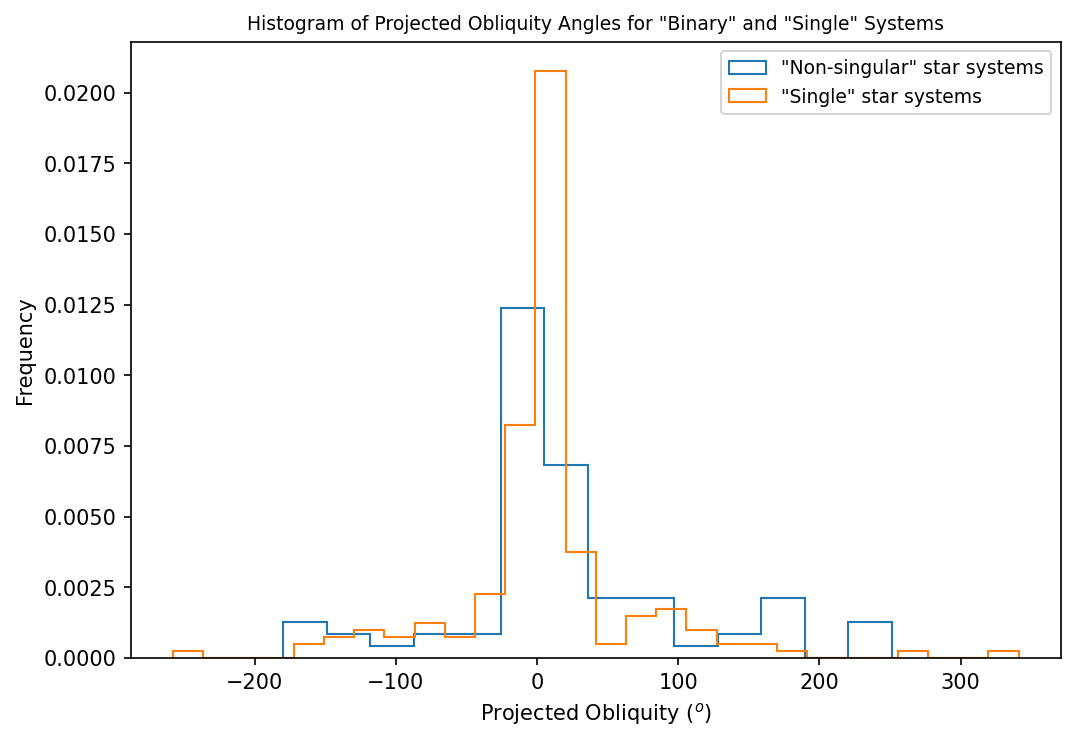

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.hist(binary_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.title('Histogram of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=1);

plt.show()

# Calculate the mean and standard deviation of the two populations as well
prmpt = r'\text{For single star systems, mean and standard deviation of projected obliquity angles are: }'
std_txt = f'{np.std(single_sys['pl_projobliq']):.3f}'
avg_txt = f'{np.mean(single_sys['pl_projobliq']):.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

prmpt = r'\text{For binary star systems, mean and standard deviation of projected obliquity angles are: }'
std_txt = f'{np.std(binary_sys['pl_projobliq']):.3f}'
avg_txt = f'{np.mean(binary_sys['pl_projobliq']):.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

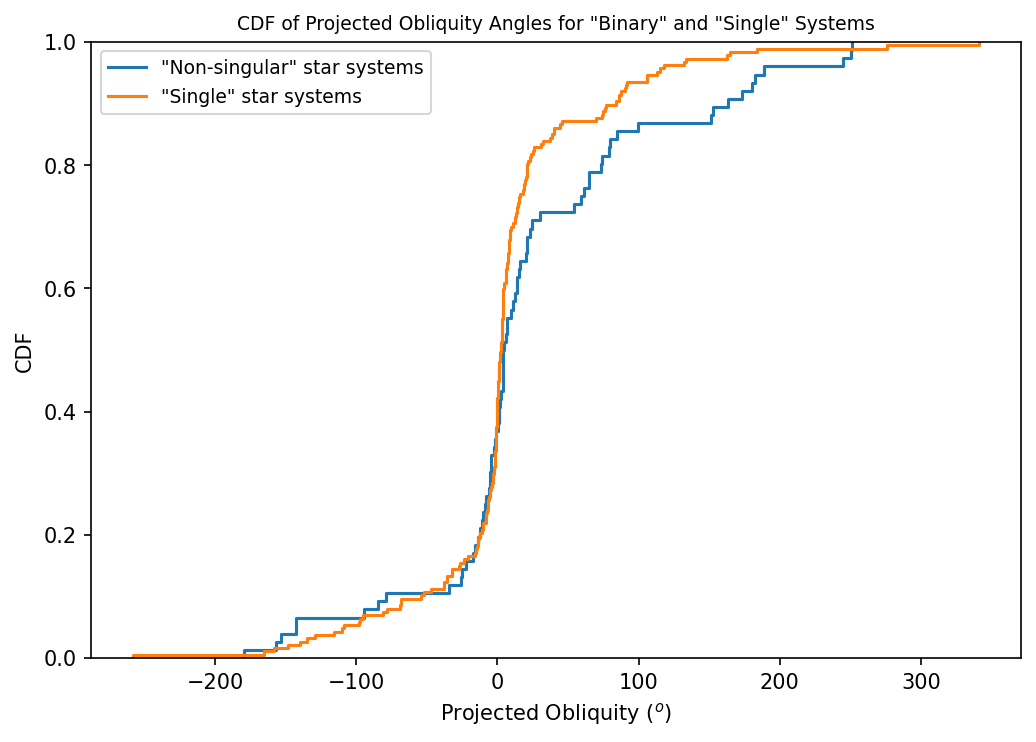

In [7]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.ecdf(binary_sys['pl_projobliq']);
plt.ecdf(single_sys['pl_projobliq']);
plt.title('CDF of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('CDF');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=2);

plt.show()

In [8]:
from scipy import stats

In [9]:
# Calculating D and p-value for the 2-sample K-S test on the two datasets
# ('binary_sys' vs. 'single_sys')
ks_d, ks_p = stats.kstest(binary_sys['pl_projobliq'], single_sys['pl_projobliq'])
print(f'K-S D, p-value: {ks_d:0.4f} {ks_p:0.4}')

K-S D, p-value: 0.1480 0.1659


In [10]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
#  on the two datasets ('binary_sys' vs. 'single_sys')
ad = stats.anderson_ksamp([binary_sys['pl_projobliq'], single_sys['pl_projobliq']], variant='midrank', method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad.statistic:0.4f} {ad.pvalue:0.4}')


A-D statistics and p-value: 1.4780 0.0843


#### 1.1 Gaia Data Retrieval

Used the following query to get the Gaia data for the list of exoplanets in our exo_table above:

SELECT * 
FROM gaiaedr3.gaia_source 
WHERE source_id IN (6794047652729201024,
3105507886130792448,
4285511294172309504,
3120058170178779392,
3120002649138831360,
4287820848378092672,
4263427117767106816,
4477340334766250496,
3393939030531019520,
457317534880081152,
1928431764627661440,
2086512227851023872,
2086512227851023872,
1499514786891168640,
1014520826353577088,
1340497608486742400,
179498266829041664,
381592313648387200,
1849786481032616960,
1849786481032616960,
1849786481032616960,
1334573817793362560,
1380825667768742144,
869913435026514688,
770622651659107712,
846946629987527168,
1808938730710633984,
3167323052618369408,
1159336403336463872,
359058441314838528,
1510191594552968832,
1510191594552968832,
3096441729861716224,
356348286886230272,
893550942158776832,
1810218734058821632,
1541532207133249920,
1291120362349158016,
4290415081653653632,
1835842749465226368,
3385777286999240576,
1925321658551399040,
3080104185367102592,
2129256395211984000,
3291455819447952768,
1891507552826485632,
898130030131443584,
6805149288493408640,
3492502001623237888,
3492502001623237888,
6805886373600546176,
5605119586158973440,
3698307419878650240,
3698307419878650240,
2248126315275354496,
2554032474712538880,
2554032474712538880,
2554032474712538880,
875071278432954240,
875071278432954240,
3877070590167177344,
600698184764497664,
600698184764497664,
6113920619134019456,
651907079835937280,
3311804515502788352,
3311804515502788352,
3807826337147474176,
6239702034929248512,
150054788545735424,
6253844468883543680,
6253844468883543680,
665757593450097920,
2881784280929695360,
6710517793025165696,
3761497761876022400,
651935220461650560,
1612165353793791488,
3142847477107193344,
2033123654092592384,
2054523105274216704,
1644692064543192704,
1076970406751899008,
1076970406751899008,
1076970406751899008,
806492023789218688,
727624020367528576,
727624020367528576,
1464700950221781504,
1464700950221781504,
181908842994567936,
2064327278651198336,
2073860662955260416,
2126633166627436928,
2130632159136095104,
2076970047474270208,
2076483616656410496,
2086449761846310784,
2100451630105041152,
2100451630105041152,
2100243616248608896,
2100243616248608896,
2100243616248608896,
2075998903831657472,
2132628489996257920,
2132628489996257920,
2116730994965905280,
2099925719951103872,
1744911763437512064,
1744911763437512064,
5245968236116294016,
5245968236116294016,
2244830490514284928,
3620030644476623616,
1265513389372846848,
995754258812449024,
6715688452614516736,
1726858366624544640,
1677343097418015488,
2241587416547315584,
1675923009431370880,
1675923009431370880,
1675923009431370880,
1978027916667478656,
5723638723350902400,
1651911084230149248,
1428639816392087552,
3719927426253118848,
2259354802894412928,
5489726768531119616,
5388416255319817856,
2296342614570999552,
1490845584382687232,
1344163891352965632,
4641274773980363520,
6828814283414902912,
178924390478792320,
3919169687804622336,
1111639314047794944,
2997312063605005056,
6027376203516634112,
2099011888349441536,
5289275864525400704,
5289275864525400704,
4657949756881138176,
114340658009875072,
3815937670648091392,
2640121486388076032,
430269136520563200,
5580554052549277056,
5313031504751276032,
5313031504751276032,
3607877948613218304,
4665704096987467776,
4683737294569921664,
2993658970584498048,
3010759262610139776,
2974906868489280768,
2635476908753563008,
2635476908753563008,
2635476908753563008,
2098964849867337856,
2131314401800665344,
4609062308806929152,
51886335968692480,
51886335968692480,
2862548428079638912,
4675352109659600000,
4439085988769170432,
3788394461991295488,
3788394461991295488,
3578638842054261248,
3578638842054261248,
3578638842054261248,
123376685084303360,
4746157737910069888,
3435282862461427072,
5565050255701441664,
5565050255701441664,
702295464353437952,
6173451477191225984,
2441013811932929280,
1242084170974175232,
1358355738906114816,
1358355738906114816,
6171009049549197824,
2514360548993901312,
6283723285046532864,
5664957444179338240,
5664957444179338240,
6154982877300947840,
6042793005779654656,
6086712585429729536,
2323985539482908416,
6139403450370668800,
6003809889735481856,
4955371367334610048,
3070964117005132416,
2790691147020786816,
6339097679918871168,
6339097679918871168,
5411736896952029568,
4994237247949280000,
5453063823882876032,
1748596020745038208,
2359978293137038720,
5086537022856406272,
1153682508388170112,
6186950525042445824,
2416782701664155008,
2416782701664155008,
2641087471777046016,
2641087471777046016,
2095108312831835648,
3545873945303316224,
2546413408888429696,
328636019723252096,
4453211899986180352,
4453211899986180352,
3643098875168270592,
6535499658122055552,
6535499658122055552,
6160877943251930368,
3767805209112436736,
2613413008919918976,
2613413008919918976,
2991284369063612928,
6533307957785865856,
5160557726183065984,
2666015878575546496,
2666015878575546496,
5136559128264765184,
2841043011433969152,
2385171398768647552,
2868528637464028160,
2959177048983750016,
4756649415309914240,
5444147952811517696,
6910753016653587840,
6910753016653587840,
6681720724498802176,
2507901914613201024,
2507901914613201024,
5065640460769428224,
4224062406762625152,
2512326349403275520,
2512326349403275520,
5089851638095503616,
4884779765893739904,
2312679845530628096,
2312679845530628096,
4223507222112425344,
3078836109158636928,
3909745223886018432,
6077185317188247936,
6780546169634170496,
934346809278715776,
470650560779277952,
470650560779277952,
990291507088739072,
1114308481603347584,
2303332931542914048,
4623036865373793408
)

In [11]:
# Read in a list of stars from the Gaia database where their Gaia DR3 id
# matches those in our Exoplanet dataset above
data_file_loc = '../data/'
gaia_file_name = 'Gaia-Cross-Ref-20260515.csv'
gaia_table = table.Table.read(data_file_loc+gaia_file_name, format='ascii.csv')

In [12]:
masked_columns = [[col, np.ma.count_masked(gaia_table[col]).tolist()] for col in gaia_table.colnames if np.any(gaia_table.mask[col])]
print(masked_columns)
gaia_table.colnames

[['nu_eff_used_in_astrometry', 17], ['pseudocolour', 199], ['pseudocolour_error', 199], ['ra_pseudocolour_corr', 199], ['dec_pseudocolour_corr', 199], ['parallax_pseudocolour_corr', 199], ['pmra_pseudocolour_corr', 199], ['pmdec_pseudocolour_corr', 199], ['scan_direction_strength_k1', 200], ['scan_direction_strength_k2', 200], ['scan_direction_strength_k3', 200], ['scan_direction_strength_k4', 200], ['scan_direction_mean_k1', 200], ['scan_direction_mean_k2', 200], ['scan_direction_mean_k3', 200], ['scan_direction_mean_k4', 200], ['dr2_radial_velocity', 49], ['dr2_radial_velocity_error', 49], ['dr2_rv_template_teff', 49], ['dr2_rv_template_logg', 49], ['dr2_rv_template_fe_h', 49]]


['solution_id',
 'designation',
 'source_id',
 'random_index',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'ra_dec_corr',
 'ra_parallax_corr',
 'ra_pmra_corr',
 'ra_pmdec_corr',
 'dec_parallax_corr',
 'dec_pmra_corr',
 'dec_pmdec_corr',
 'parallax_pmra_corr',
 'parallax_pmdec_corr',
 'pmra_pmdec_corr',
 'astrometric_n_obs_al',
 'astrometric_n_obs_ac',
 'astrometric_n_good_obs_al',
 'astrometric_n_bad_obs_al',
 'astrometric_gof_al',
 'astrometric_chi2_al',
 'astrometric_excess_noise',
 'astrometric_excess_noise_sig',
 'astrometric_params_solved',
 'astrometric_primary_flag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'pseudocolour_error',
 'ra_pseudocolour_corr',
 'dec_pseudocolour_corr',
 'parallax_pseudocolour_corr',
 'pmra_pseudocolour_corr',
 'pmdec_pseudocolour_corr',
 'astrometric_matched_transits',
 'visibility_periods_used',
 'astrometric_sigma5d_max

In [13]:
print(gaia_table['pm'].data)

[8.83394000e+01 1.48010340e+01 6.09987000e+01 1.61635280e+01
 2.99126380e+01 6.87069850e+01 3.93281200e+01 5.74800800e+00
 1.43156210e+01 6.11671540e+00 1.11488080e+02 1.41863390e+02
 1.01179695e+01 9.71182900e+01 1.70607500e+01 4.38274960e+01
 6.86264400e+01 3.54139420e+00 6.58394300e+01 7.63552430e+00
 1.09045450e+01 3.27695510e+00 3.09400250e+00 5.66357000e+01
 2.20173100e+01 7.61571040e+01 5.43819100e+01 2.45846400e+00
 8.34730000e+00 8.25559000e+01 7.39621350e+00 7.34872800e+01
 8.32750800e+00 2.43974670e+01 1.90458800e+01 1.35711070e+01
 5.21980550e+01 1.15986350e+01 8.77794900e+01 1.69396500e+01
 2.04777410e+01 6.92905660e+00 2.36236270e+01 5.65758470e+00
 3.92632500e+01 1.31906450e+01 7.29778430e+00 1.84739930e+01
 1.78638380e+01 2.82444320e+01 1.21423110e+01 4.23675970e+00
 3.24210930e+01 4.41215250e+01 3.64772150e+01 5.00340650e+01
 4.88173500e+01 1.25740800e+01 1.10016060e+02 1.88009990e+01
 2.23584400e+01 5.30179300e+01 2.62486480e+00 5.65372700e+00
 5.66643400e+00 4.470315

In [14]:
# Extract those stars whose RUWE > 1.4
possible_binary_sys = gaia_table[gaia_table['ruwe'] > 1.4]['designation', 'source_id', 'ruwe']

# Using the ids of the stars in the list above, extract exoplanets listed
# as sinble start systems which could be "possible" binary systems
include_col = ['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
possible_binary_sys = table.join(possible_binary_sys, exo_table, keys_left='source_id',
                                 keys_right='gaia_dr3_source_id')[include_col]
possible_binary_sys = possible_binary_sys[possible_binary_sys['sy_snum'] == 1]
print(possible_binary_sys)

 gaia_dr3_source_id discoverymethod sy_snum pl_projobliq
------------------- --------------- ------- ------------
2546413408888429696         Transit       1         -2.0
3578638842054261248         Transit       1         90.0
3578638842054261248         Transit       1        118.1
3578638842054261248         Transit       1       -158.0
4439085988769170432         Transit       1          3.0
4641274773980363520         Transit       1         26.0
5065640460769428224         Transit       1         -7.0
5086537022856406272         Transit       1         22.0
5444147952811517696         Transit       1         -4.0
6173451477191225984         Transit       1        162.4


In [15]:
# Modify the two original lists of exoplanets to now include "possible" binary
# systems in the exoplanets with binary system list:
#   Add the list of items from "possible_binary_sys" to the original
#   "binary_sys" list
binary_sys_ruwe = table.vstack([binary_sys, possible_binary_sys])
binary_sys_ruwe = table.join(gaia_table, binary_sys_ruwe, keys_left='source_id',
                             keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe', 'pm']

#   Extract those stars whose RUWE <= 1.4
single_sys_ruwe = gaia_table[gaia_table['ruwe'] <= 1.4]['designation', 'source_id', 'ruwe', 'pm']

#   Using the ids of the stars in the list above, extract the corresponding
#   exoplanet data for "single" star systems
single_sys_ruwe = table.join(single_sys_ruwe, single_sys, keys_left='source_id',
                             keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe', 'pm']
print(binary_sys_ruwe['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe', 'pm'], '\n')
print(single_sys_ruwe['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe', 'pm'], '\n')

print(f'Mean RUWE for "binary" star systems: {np.mean(binary_sys_ruwe['ruwe']):.2f}\n')
print(f'Mean RUWE for "single" star systems: {np.mean(single_sys_ruwe['ruwe']):.2f}\n')


 gaia_dr3_source_id discoverymethod sy_snum pl_projobliq    ruwe        pm    
------------------- --------------- ------- ------------ ---------- ----------
  51886335968692480         Transit       3          4.0  1.0351886   16.93965
  51886335968692480         Transit       3          4.9  1.0351886   16.93965
 123376685084303360         Transit       3          7.0  3.5986927  44.558315
 150054788545735424         Transit       2          1.5  1.3586797  27.460817
 178924390478792320         Transit       2         21.0  1.1511657   73.48728
 328636019723252096         Transit       2        251.2 0.99838525   8.948317
 356348286886230272         Transit       2         85.0 0.77617514 10.3224745
 359058441314838528         Transit       2        -26.0  1.0203094  10.131743
 381592313648387200         Transit       3        -10.0  0.8328063   22.01731
 727624020367528576         Transit       3         80.0     1.0232  18.606537
                ...             ...     ...         

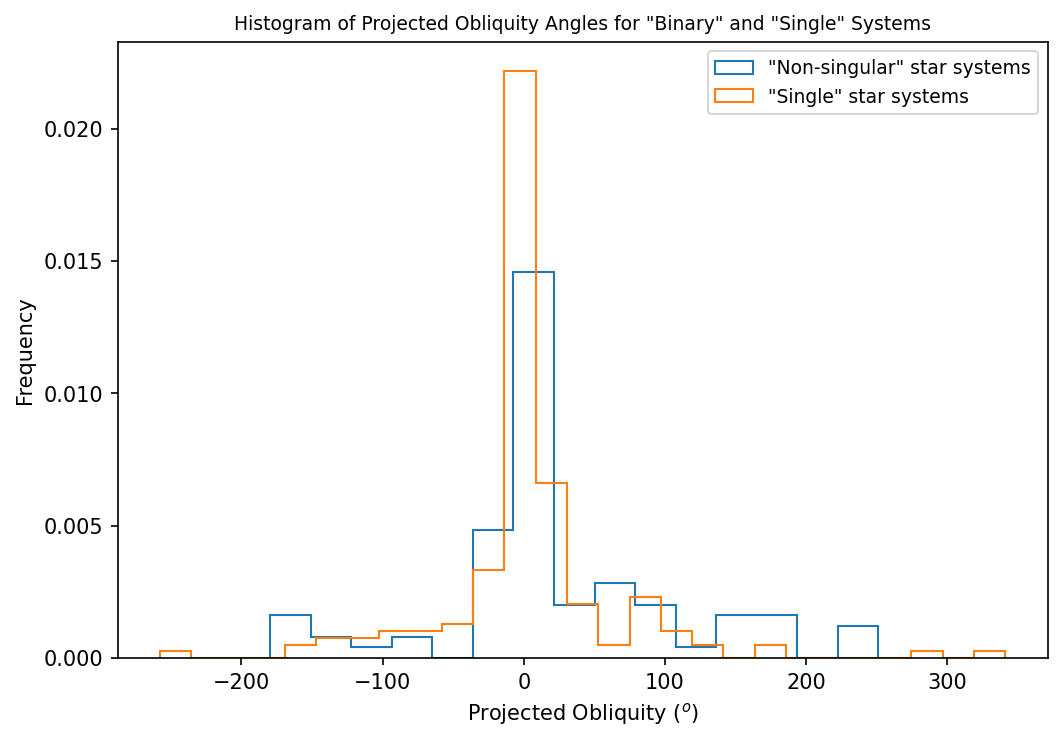

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.hist(binary_sys_ruwe['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys_ruwe['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.title('Histogram of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=1);

plt.show()

# Calculate the mean and standard deviation of the two populations as well
prmpt = r'\text{For single star systems, mean and standard deviation of projected obliquity angles are: }'
std_txt = f'{np.std(single_sys_ruwe['pl_projobliq']):.3f}'
avg_txt = f'{np.mean(single_sys_ruwe['pl_projobliq']):.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

prmpt = r'\text{For binary star systems, mean and standard deviation of projected obliquity angles are: }'
std_txt = f'{np.std(binary_sys_ruwe['pl_projobliq']):.3f}'
avg_txt = f'{np.mean(binary_sys_ruwe['pl_projobliq']):.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

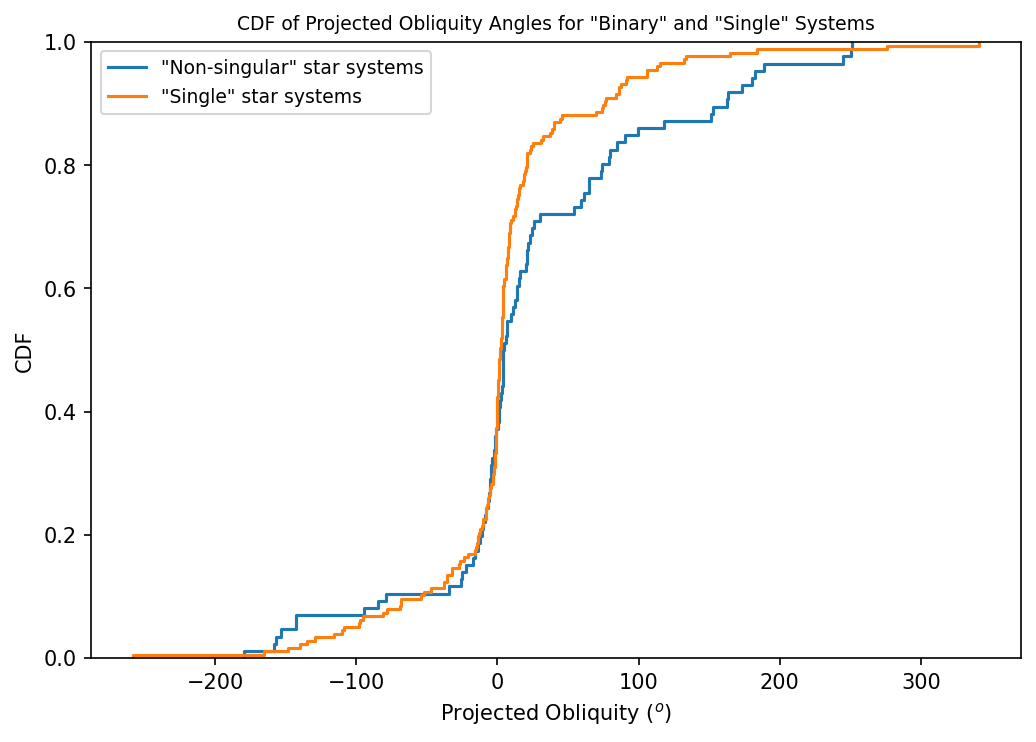

In [17]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.ecdf(binary_sys_ruwe['pl_projobliq']);
plt.ecdf(single_sys_ruwe['pl_projobliq']);
plt.title('CDF of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('CDF');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=2);

plt.show()

In [18]:
# Calculating D and p-value for the 2-sample K-S test on the two datasets
# ('binary_sys' vs. 'single_sys')
ks_d, ks_p = stats.kstest(binary_sys_ruwe['pl_projobliq'], single_sys_ruwe['pl_projobliq'])
print(f'K-S D, p-value: {ks_d:0.4f} {ks_p:0.4}')

K-S D, p-value: 0.1631 0.07987


In [19]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
#  on the two datasets ('binary_sys' vs. 'single_sys')
ad = stats.anderson_ksamp([binary_sys_ruwe['pl_projobliq'], single_sys_ruwe['pl_projobliq']], variant='midrank', method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad.statistic:0.4f} {ad.pvalue:0.4}')


A-D statistics and p-value: 2.5091 0.0307


#### Correlation Testing

In this section we would like to examine whether projected obliquity data is correlated to the RUWE data.

In [37]:
# List of all planets (star systems) with projected obliquities
all_proj_obliq = table.vstack([single_sys_ruwe, binary_sys_ruwe])

# List of planets in verified non-single star systems
only_bin_sys_ruwe = binary_sys_ruwe[binary_sys_ruwe['sy_snum'] > 1]
# only_bin_sys_ruwe = binary_sys_ruwe[binary_sys_ruwe['ruwe'] > 1.4]

# List of planets in listed single star systems regardless of the RUWE number
single_bin_sys_ruwe = binary_sys_ruwe[binary_sys_ruwe['sy_snum'] == 1]

# List of planets in star (either single or non-single) systems whose RUWE
# numbers are less than 1.4
all_fit_ruwe = all_proj_obliq[all_proj_obliq['ruwe'] <= 1.4]

# List of planets in non-single star systems with RUWE numbers less than 1.4
bin_fit_ruwe = binary_sys_ruwe[binary_sys_ruwe['ruwe'] <= 1.4]

# print(only_bin_sys_ruwe == bin_fit_ruwe)
# print(table.setdiff(only_bin_sys_ruwe, bin_fit_ruwe, ['gaia_dr3_source_id', 'pl_projobliq']))
# print(table.setdiff(binary_sys_ruwe, bin_fit_ruwe, ['gaia_dr3_source_id', 'pl_projobliq']))

# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(single_sys_ruwe['pl_projobliq'], single_sys_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for single star systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(single_sys_ruwe['pl_projobliq'], single_sys_ruwe['ruwe'])
print(f'The Spearman rho statistics for single star systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
print(f'The max RUWE for this group is {np.max(single_sys_ruwe['ruwe'])} with a size of {len(single_sys_ruwe['ruwe'])}')

# Calculating Pearson r statistic
# pearson_r, pearson_p = stats.pearsonr(binary_sys_ruwe['pl_projobliq'], binary_sys_ruwe['ruwe'])
# print(f'\nThe Pearson r statistics for "binary" star systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# # Calculating Spearman rho statistic
# spearman_rho, spearman_p = stats.spearmanr(binary_sys_ruwe['pl_projobliq'], binary_sys_ruwe['ruwe'])
# print(f'The Spearman rho statistics for "binary" star systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
# print(f'The max RUWE for this group is {np.max(binary_sys_ruwe['ruwe'])}')

# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(bin_fit_ruwe['pl_projobliq'], bin_fit_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for "binary" star systems with RUWE < 1.4 is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(bin_fit_ruwe['pl_projobliq'], bin_fit_ruwe['ruwe'])
print(f'The Spearman rho statistics for "binary" star systems with RUWE < 1.4 is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
print(f'The max RUWE for this group is {np.max(bin_fit_ruwe['ruwe'])} with a size of {len(bin_fit_ruwe['ruwe'])}')

# Calculating Pearson r statistic
# pearson_r, pearson_p = stats.pearsonr(only_bin_sys_ruwe['pl_projobliq'], only_bin_sys_ruwe['ruwe'])
# print(f'\nThe Pearson r statistics for "only" binary systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# # Calculating Spearman rho statistic
# spearman_rho, spearman_p = stats.spearmanr(only_bin_sys_ruwe['pl_projobliq'], only_bin_sys_ruwe['ruwe'])
# print(f'The Spearman rho statistics for "only" binary systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
# print(f'The max RUWE for this group is {np.max(only_bin_sys_ruwe['ruwe'])}')

# Calculating Pearson r statistic
# pearson_r, pearson_p = stats.pearsonr(single_bin_sys_ruwe['pl_projobliq'], single_bin_sys_ruwe['ruwe'])
# print(f'\nThe Pearson r statistics for "single" binary systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# # Calculating Spearman rho statistic
# spearman_rho, spearman_p = stats.spearmanr(single_bin_sys_ruwe['pl_projobliq'], single_bin_sys_ruwe['ruwe'])
# print(f'The Spearman rho statistics for "single" binary systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
# print(f'The max RUWE for this group is {np.max(single_bin_sys_ruwe['ruwe'])}')

# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(all_proj_obliq['pl_projobliq'], all_proj_obliq['ruwe'])
print(f'\nThe Pearson r statistics for "all" star systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(all_proj_obliq['pl_projobliq'], all_proj_obliq['ruwe'])
print(f'The Spearman rho statistics for "all" star systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
print(f'The max RUWE for this group is {np.max(all_proj_obliq['ruwe'])}')

# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(all_fit_ruwe['pl_projobliq'], all_fit_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for all star systems with RUWE < 1.4 is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(all_fit_ruwe['pl_projobliq'], all_fit_ruwe['ruwe'])
print(f'The Spearman rho statistics for all star systems with RUWE < 1.4 is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')
print(f'The max RUWE for this group is {np.max(all_fit_ruwe['ruwe'])} with a size of {len(all_fit_ruwe['ruwe'])}')



The Pearson r statistics for single star systems is 0.1585 with a p-value of 0.0351
The Spearman rho statistics for single star systems is 0.1871 with a p-value of 0.0127
The max RUWE for this group is 1.3267425 with a size of 177

The Pearson r statistics for "binary" star systems with RUWE < 1.4 is -0.2359 with a p-value of 0.0510
The Spearman rho statistics for "binary" star systems with RUWE < 1.4 is -0.2539 with a p-value of 0.0353
The max RUWE for this group is 1.3586797 with a size of 69

The Pearson r statistics for "all" star systems is 0.0285 with a p-value of 0.6450
The Spearman rho statistics for "all" star systems is 0.0795 with a p-value of 0.1987
The max RUWE for this group is 33.529186

The Pearson r statistics for all star systems with RUWE < 1.4 is 0.0096 with a p-value of 0.8805
The Spearman rho statistics for all star systems with RUWE < 1.4 is 0.0527 with a p-value of 0.4103
The max RUWE for this group is 1.3586797 with a size of 246


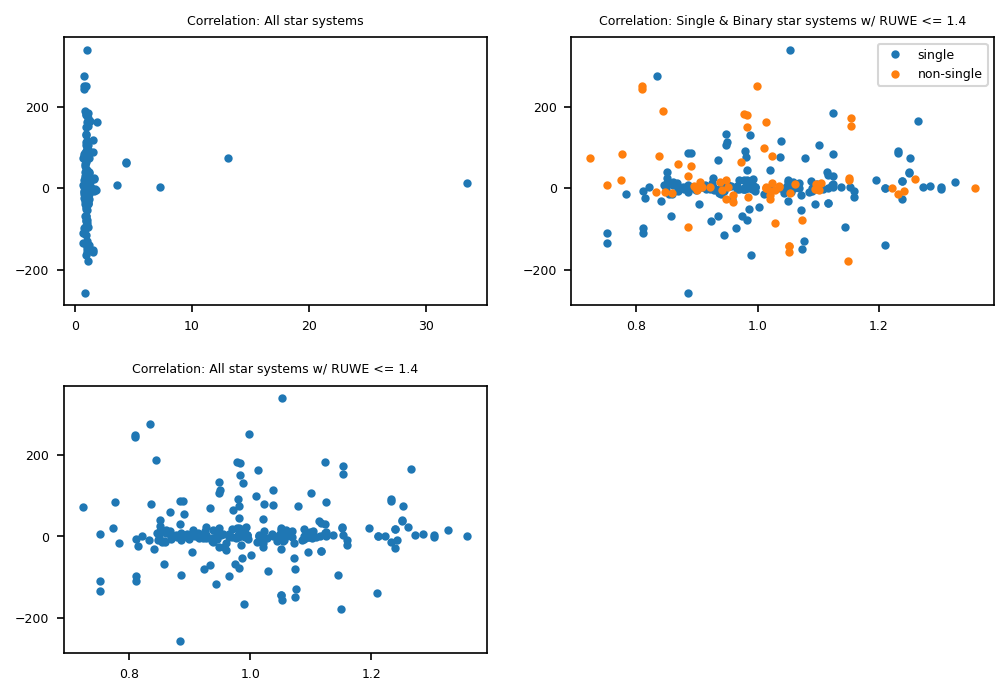

In [44]:
# Plot the Obliquity values vs. RUWE to see if there are any trends
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

plt.subplot(221)
plt.plot(all_proj_obliq['ruwe'], all_proj_obliq['pl_projobliq'], '.')
plt.title('Correlation: All star systems', fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.subplot(222)
plt.plot(single_sys_ruwe['ruwe'], single_sys_ruwe['pl_projobliq'], '.', label='single')
# plt.title('Correlation: Single star systems w/ RUWE <= 1.4', fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.subplot(222)
plt.plot(bin_fit_ruwe['ruwe'], bin_fit_ruwe['pl_projobliq'], '.', label='non-single')
plt.title('Correlation: Single & Binary star systems w/ RUWE <= 1.4', fontsize=6)
plt.legend(fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.subplot(223)
plt.plot(all_fit_ruwe['ruwe'], all_fit_ruwe['pl_projobliq'], '.')
plt.title('Correlation: All star systems w/ RUWE <= 1.4', fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.subplots_adjust(hspace=.3)


### 2. Clustering

In this setion we use the data features (number of stars, RUWE, projected obliquity) to see if the data can be clustered into two different classes.

In [22]:
# Import clusterring related libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

 gaia_dr3_source_id discoverymethod sy_snum ...    ruwe        pm     label
------------------- --------------- ------- ... ---------- ---------- -----
3620030644476623616         Transit       1 ...  1.0180421  89.469215     0
3643098875168270592         Transit       1 ...  1.0594568   19.04588     0
3698307419878650240         Transit       1 ... 0.93699294  12.173809     0
3698307419878650240         Transit       1 ... 0.93699294  12.173809     0
3719927426253118848         Transit       1 ... 0.85676926  24.854477     0
3761497761876022400         Transit       1 ... 0.98203003  111.48808     0
3767805209112436736         Transit       1 ...  1.1534084    56.6357     0
3788394461991295488         Transit       1 ...  0.9654871  28.003206     0
3788394461991295488         Transit       1 ...  0.9654871  28.003206     0
3807826337147474176         Transit       1 ...  1.1161277   49.88264     0
                ...             ...     ... ...        ...        ...   ...
468373729456

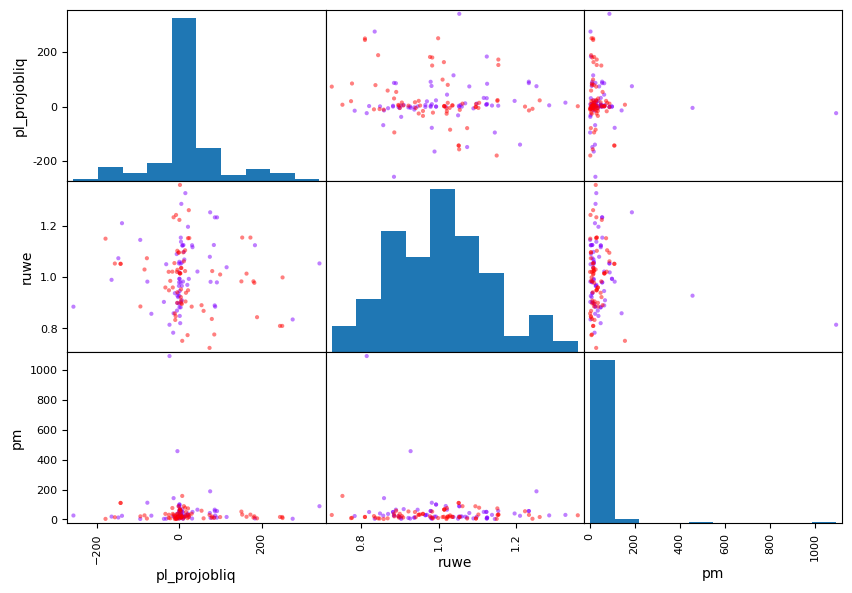

In [47]:
fig_w = 10
fig_h = fig_w * 6 / 9

# feature_list = ['sy_snum', 'pl_projobliq', 'ruwe']
feature_list = ['pl_projobliq', 'ruwe', 'pm']
# pd_dataset = all_proj_obliq[feature_list].to_pandas()

# Create a label column labeling data based on whether a system is single
# or non-single
if 'label' not in all_proj_obliq.colnames:
    label = np.ones_like(all_proj_obliq['sy_snum'])
    label[all_proj_obliq['sy_snum'] == 1] = 0
    all_proj_obliq.add_column(table.Column(label, name='label'))

# Include only data with RUWE < 1.4
train_data = all_proj_obliq[all_proj_obliq['ruwe'] < 1.4]

# Make the dataset equal sized between single and non-single systems
train_data = train_data[109:-1]


train_data.pprint()
print(f'\nNumber of data points with single star systems: {len(train_data[train_data['sy_snum'] == 1])}')
print(f'Number of data points with non-single star systems: {len(train_data[train_data['sy_snum'] > 1])}\n')

pd_dataset = train_data[feature_list].to_pandas()
pd.plotting.scatter_matrix(pd_dataset, c=train_data['label'], cmap='rainbow', figsize=[fig_w, fig_h]);

In [24]:
# Initialize the Scaler with default setting
scaler = StandardScaler()

# Train the Scaler with iris data
scaler.fit(pd_dataset)

# Whiten the iris data using the mean and variance calculated in the previous step
wht_dataset = pd.DataFrame(scaler.transform(pd_dataset), columns=['Projected Obliquity', 'RUWE', 'Proper Motion'])
# wht_dataset = pd_dataset


In [25]:
kmeans2 = KMeans(n_clusters=2)
kmeans2.fit(wht_dataset)
clusters2 = kmeans2.predict(wht_dataset)
print(clusters2)

[0 0 1 1 1 0 0 1 1 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 1 1
 0 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1
 0 1 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1 0 1 0 0 0
 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 0 1]


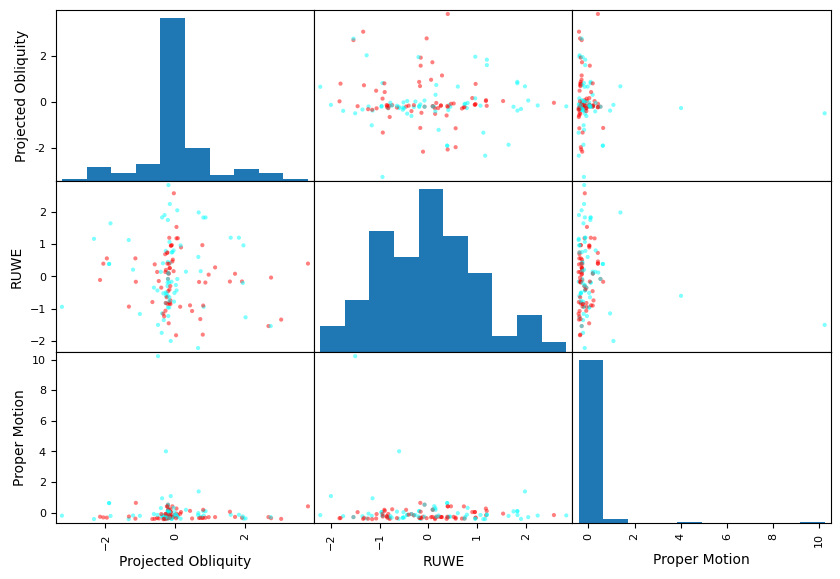

In [26]:
def scatter_plot(dataset, clusters, col_names=None, fig_w=10,
                 plt_color=np.array(['black', 'cyan', 'red', 'green', 'orange', 'blue', 'brown'])):

    # Set the figure size
    fig_h = fig_w * 6 / 9
    
    # Create a color list for the two clusters
    colors = np.empty_like(clusters, dtype=plt_color.dtype)
    
    # Go thru all the unique cluster labels, and...
    for i, cluster in enumerate(np.unique(clusters)):
        # ...assign colors from the plt_color list to each unique label, and...
        colors[clusters==cluster]  = plt_color[i]
    
        # ...group and sort iris data based on the cluster labels
        if i == 0:
            data_cluster = dataset[clusters==cluster]
        else:
            data_cluster = np.concat((data_cluster, dataset[clusters==cluster]))
        
    
    
    # Convert the grouped and sorted data back to pandas Data Frames and plot them
    data_cluster = pd.DataFrame(data_cluster, columns=col_names)
    pd.plotting.scatter_matrix(data_cluster, color=colors, figsize=[fig_w, fig_h]);

# scatter_plot(pd_dataset, clusters2, plt_color=np.array(['cyan', 'red', 'green']),
#                                                        col_names=['Number of Stars', 'Projected Obliquity', 'RUWE'])
scatter_plot(wht_dataset, clusters2, plt_color=np.array(['cyan', 'red', 'green']),
                                                       col_names=['Projected Obliquity', 'RUWE', 'Proper Motion'])

In [27]:
# Initialize the Principal Component Analysis class with 2 principal components
pca = PCA(n_components=2)

# Train the Principal Component Analysis class with the iris data
pca.fit(pd_dataset)
print(f'\nThe captured variances by the top 2 components are: {pca.explained_variance_ratio_}\n')

# Perform the projection on the iris data
pca_data = pd.DataFrame(pca.transform(pd_dataset), columns=['Component 1', 'Component 2'])
#print(np.mean(data_pca, axis=0), '\n\n', np.var(data_pca, axis=0))

# Run Kmeans clustering again, now on the whitened data
kmeans2 = KMeans(n_clusters=2)              # Setting number of clusters to 2
kmeans2.fit(pca_data)                       # Training the Kmeans algo
pca_clusters2 = kmeans2.predict(pca_data)   # Determining the clusters
print(pca_clusters2)



The captured variances by the top 2 components are: [0.5968095  0.40318963]

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### 2. Classification

In this setion we use the data features (RUWE, projected obliquity, star's mass...) to see if the data can be classified into two different classes. Number of verified stars (> 1 or = 1) is used as the labels for training.

In [28]:
# Import classification related libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [29]:
print(wht_dataset)

     Projected Obliquity      RUWE  Proper Motion
0              -0.212557  0.119888       0.423083
1              -0.212557  0.449406      -0.264519
2              -0.244063 -0.524983      -0.331617
3              -0.340699 -0.524983      -0.331617
4              -1.013154 -1.163286      -0.207805
..                   ...       ...            ...
131            -0.165532 -0.753507      -0.327153
132            -0.306606  1.900104      -0.409400
133             1.821267  1.199413      -0.139526
134             1.586143  1.199413      -0.139526
135             1.562631 -0.159143       0.059173

[136 rows x 3 columns]


In [30]:
# Create a classifier instance of KNN with 5 neighbors
num_neigbor = 2
knn_clf05 = KNeighborsClassifier(n_neighbors=num_neigbor)

# Create a K-Fold splitter instance with randomizer turned on
kf_splits = 20
kf = KFold(n_splits=kf_splits, shuffle=True, random_state=12345)

labels05 = cross_val_predict(knn_clf05, wht_dataset, train_data['label'].data, cv=kf)
# train_data['label'].pprint()
# print(train_data['label'].data)
print('\n')
print(labels05)

acc_score05 = accuracy_score(train_data['label'].data, labels05, normalize=True)
print(f'\nAccuracy score: {acc_score05:0.2%}\n')




[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1
 0 0 0 1 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1]

Accuracy score: 59.56%



In [31]:
# Create a classifier instance of KNN with 5 neighbors
rf_clf = RandomForestClassifier(n_estimators=100, criterion='entropy', min_samples_split=2)

# Create a K-Fold splitter instance with randomizer turned on
kf_splits = 20
kf = KFold(n_splits=kf_splits, shuffle=True, random_state=12345)

rf_labels = cross_val_predict(rf_clf, wht_dataset, train_data['label'].data, cv=kf)
print(rf_labels)
print(len(rf_labels), len(train_data['label']))

# Given the predicted results, compute the accuracy score
rf_acc_score = accuracy_score(train_data['label'].data, rf_labels, normalize=True)
print(f'\nAccuracy score: {rf_acc_score:0.2%}\n')


[0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1
 0 1 1 0 0 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1
 1 0 0 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1 1]
136 136

Accuracy score: 62.50%



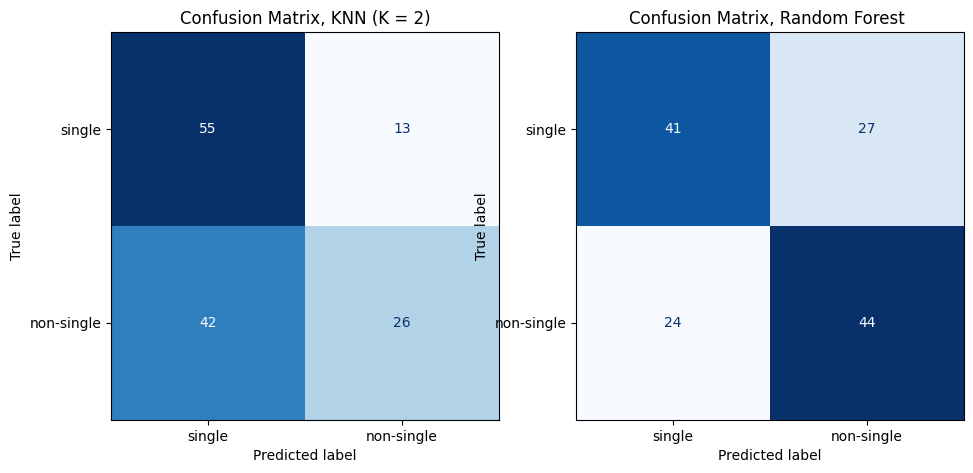

In [32]:
fig_w = 11
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h])

ax = plt.subplot(121)
ax.set_aspect('equal')
ConfusionMatrixDisplay.from_predictions(train_data['label'].data, labels05, display_labels=['single', 'non-single'],
                                        cmap='Blues', colorbar=False, ax=ax)
plt.title(f'Confusion Matrix, KNN (K = {num_neigbor})')

ax = plt.subplot(122)
ax.set_aspect('equal')
ConfusionMatrixDisplay.from_predictions(train_data['label'].data, rf_labels, display_labels=['single', 'non-single'],
                                        cmap='Blues', colorbar=False, ax=ax)
plt.title('Confusion Matrix, Random Forest ')

plt.show()
